In [18]:
import pandas as pd
from pathlib import Path

# Load tallo.csv
data_path = Path(r'C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\tallo.csv')
df_tallo = pd.read_csv(data_path)

print(f'✓ Loaded: {data_path}')
print(f'\nShape: {df_tallo.shape}')
print(f'\nColumns: {list(df_tallo.columns)}')
print(f'\nFirst 5 rows:')
print(df_tallo.head())
print(f'\nData types:')
print(df_tallo.dtypes)
print(f'\nBasic statistics:')
print(df_tallo.describe())

✓ Loaded: C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\tallo.csv

Shape: (498838, 13)

Columns: ['tree_id', 'division', 'family', 'genus', 'species', 'latitude', 'longitude', 'stem_diameter_cm', 'height_m', 'crown_radius_m', 'height_outlier', 'crown_radius_outlier', 'reference_id']

First 5 rows:
  tree_id    division      family   genus           species  latitude  \
0     T_1  Angiosperm  Betulaceae  Betula  Betula pubescens    67.395   
1     T_2  Gymnosperm    Pinaceae   Picea       Picea abies    67.395   
2     T_3  Gymnosperm    Pinaceae   Picea       Picea abies    67.395   
3     T_4  Gymnosperm    Pinaceae   Picea       Picea abies    67.395   
4     T_5  Gymnosperm    Pinaceae   Picea       Picea abies    67.395   

   longitude  stem_diameter_cm  height_m  crown_radius_m height_outlier  \
0     28.723              10.0       5.6            1.65              N   
1     28.723              10.0       6.6            0.85              N   
2 

In [19]:
# Filter to keep only specific species
species_to_keep = [
    'Fagus sylvatica',
    'Alnus glutinosa',
    'Fraxinus excelsior',
    'Populus nigra',
    'Pinus sylvestris',
    'Picea abies',
    'Abies alba',
    'Larix decidua'
]

print(f'Original shape: {df_tallo.shape}')
print(f'\nSpecies in dataset:')
print(df_tallo['species'].value_counts())

# Filter to keep only the specified species
df_tallo = df_tallo[df_tallo['species'].isin(species_to_keep)]

print(f'\n✓ Filtered to keep only specified species')
print(f'New shape: {df_tallo.shape}')
print(f'\nRemaining species:')
print(df_tallo['species'].value_counts())
print(f'\nFirst 5 rows:')
print(df_tallo.head())

Original shape: (498838, 13)

Species in dataset:
species
Quercus ilex               22760
Pinus sylvestris           18221
Pinus halepensis           14003
Pinus pinaster             11766
Quercus infectoria         10964
                           ...  
Lithocarpus orocola            1
Decaspermum parviflorum        1
Terminalia foetidissima        1
Syzygium fastigiatum           1
Tarenna mollis                 1
Name: count, Length: 5163, dtype: int64

✓ Filtered to keep only specified species
New shape: (37693, 13)

Remaining species:
species
Pinus sylvestris      18221
Fagus sylvatica        9470
Picea abies            6723
Fraxinus excelsior     1082
Abies alba             1070
Populus nigra           592
Larix decidua           464
Alnus glutinosa          71
Name: count, dtype: int64

First 5 rows:
  tree_id    division    family  genus           species  latitude  longitude  \
1     T_2  Gymnosperm  Pinaceae  Picea       Picea abies    67.395     28.723   
2     T_3  Gymnosp

In [20]:
# Export filtered dataset
output_path = Path(r'C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\allometry\tallofiltered.csv')
output_path.parent.mkdir(parents=True, exist_ok=True)
df_tallo.to_csv(output_path, index=False)

print(f'✓ Exported to: {output_path}')
print(f'\nFile details:')
print(f'  - Rows: {len(df_tallo):,}')
print(f'  - Columns: {len(df_tallo.columns)}')
print(f'  - Species: {df_tallo["species"].nunique()}')
print(f'\nFile size: {output_path.stat().st_size / 1024 / 1024:.2f} MB')

✓ Exported to: C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\allometry\tallofiltered.csv

File details:
  - Rows: 37,693
  - Columns: 13
  - Species: 8

File size: 3.03 MB


In [21]:
import numpy as np
from scipy.optimize import curve_fit
from scipy.stats import linregress
import matplotlib.pyplot as plt

# Define allometric model: D = a * H^b
def allometric_model(H, a, b):
    return a * H**b

# Dictionary to store results
allometry_results = {}

print('='*80)
print('D-H ALLOMETRIC RELATIONSHIPS BY SPECIES')
print('='*80)

species_list = sorted(df_tallo['species'].unique())

for species in species_list:
    species_data = df_tallo[df_tallo['species'] == species].copy()
    
    # Remove NaN values
    species_data = species_data.dropna(subset=['stem_diameter_cm', 'height_m'])
    
    if len(species_data) < 10:  # Skip if not enough data
        continue
    
    H = species_data['height_m'].values
    D = species_data['stem_diameter_cm'].values
    
    # Fit model using curve_fit
    try:
        popt, pcov = curve_fit(allometric_model, H, D, p0=[1, 0.5], maxfev=5000)
        a, b = popt
        
        # Calculate R-squared using log-linear regression
        H_log = np.log(H)
        D_log = np.log(D)
        slope, intercept, r_value, p_value, std_err = linregress(H_log, D_log)
        r_squared = r_value**2
        
        # Store results
        allometry_results[species] = {
            'a': a,
            'b': b,
            'r_squared': r_squared,
            'n_samples': len(species_data),
            'H_min': H.min(),
            'H_max': H.max(),
            'D_min': D.min(),
            'D_max': D.max()
        }
        
        print(f'\n{species}')
        print(f'  Model: D = {a:.4f} × H^{b:.4f}')
        print(f'  R² = {r_squared:.4f}')
        print(f'  N = {len(species_data):,}')
        print(f'  H range: {H.min():.2f} - {H.max():.2f} m')
        print(f'  D range: {D.min():.2f} - {D.max():.2f} cm')
    
    except Exception as e:
        print(f'\n{species}: Error in fitting - {str(e)}')

print('\n' + '='*80)

D-H ALLOMETRIC RELATIONSHIPS BY SPECIES

Abies alba
  Model: D = 1.0937 × H^1.0885
  R² = 0.8395
  N = 1,070
  H range: 1.50 - 45.80 m
  D range: 1.10 - 113.00 cm

Alnus glutinosa
  Model: D = 1.8516 × H^0.9028
  R² = 0.6086
  N = 71
  H range: 3.50 - 34.00 m
  D range: 5.50 - 80.00 cm

Fagus sylvatica
  Model: D = 1.3980 × H^1.0083
  R² = 0.4059
  N = 8,937
  H range: 2.10 - 55.30 m
  D range: 1.70 - 162.00 cm

Fraxinus excelsior
  Model: D = 0.2672 × H^1.4309
  R² = 0.6966
  N = 1,077
  H range: 1.50 - 47.80 m
  D range: 1.00 - 112.40 cm

Larix decidua
  Model: D = 0.7511 × H^1.2213
  R² = 0.6948
  N = 460
  H range: 4.80 - 44.00 m
  D range: 5.00 - 82.00 cm

Picea abies
  Model: D = 0.7155 × H^1.1862
  R² = 0.8418
  N = 6,690
  H range: 1.40 - 48.60 m
  D range: 1.00 - 109.00 cm

Pinus sylvestris
  Model: D = 4.2424 × H^0.6485
  R² = 0.4654
  N = 17,966
  H range: 1.40 - 41.70 m
  D range: 1.00 - 98.70 cm

Populus nigra
  Model: D = 2.7410 × H^0.7973
  R² = 0.5201
  N = 592
  H rang

✓ Figure saved: DH_Curves_by_Species.png


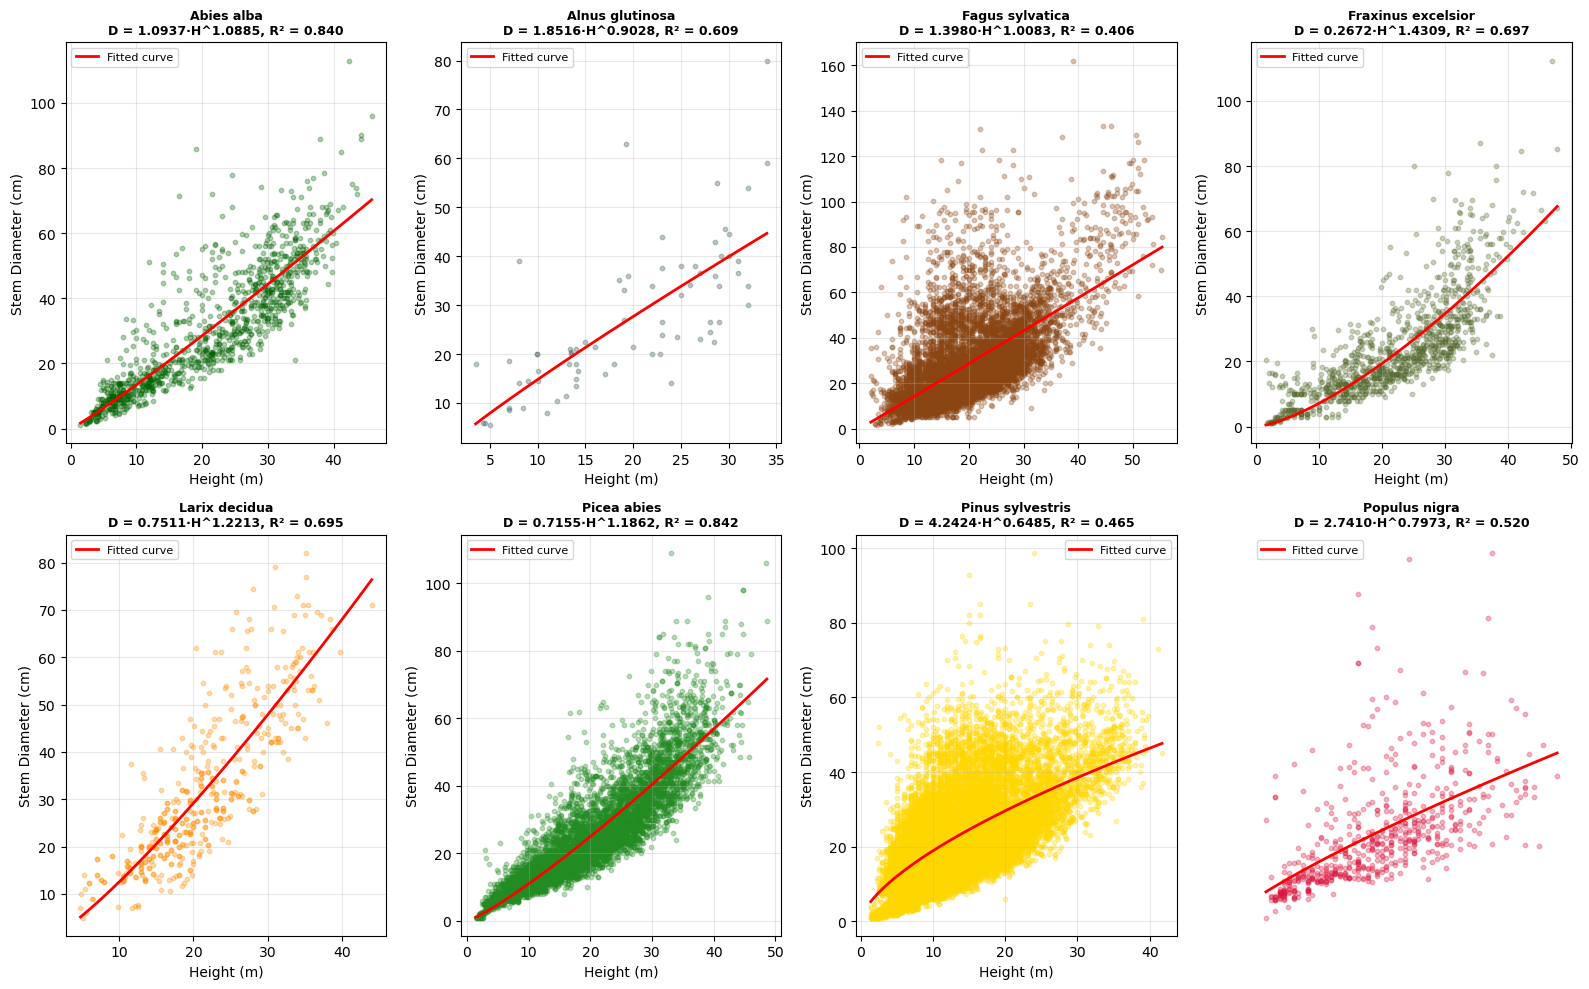

In [22]:
# Create visualization of D-H curves
colors = {
    'Fagus sylvatica': '#8B4513',      # Brown
    'Alnus glutinosa': '#2F4F4F',      # Dark slate gray
    'Fraxinus excelsior': '#556B2F',   # Dark olive green
    'Populus nigra': '#DC143C',        # Crimson
    'Pinus sylvestris': '#FFD700',     # Gold
    'Picea abies': '#228B22',          # Forest green
    'Abies alba': '#006400',           # Dark green
    'Larix decidua': '#FF8C00'         # Dark orange
}

fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.flatten()

for idx, species in enumerate(sorted(allometry_results.keys())):
    ax = axes[idx]
    
    species_data = df_tallo[df_tallo['species'] == species].dropna(subset=['stem_diameter_cm', 'height_m'])
    H = species_data['height_m'].values
    D = species_data['stem_diameter_cm'].values
    
    result = allometry_results[species]
    a, b = result['a'], result['b']
    r_sq = result['r_squared']
    
    # Plot raw data
    ax.scatter(H, D, alpha=0.3, s=10, color=colors.get(species, 'gray'))
    
    # Plot fitted curve
    H_range = np.linspace(H.min(), H.max(), 100)
    D_fitted = allometric_model(H_range, a, b)
    ax.plot(H_range, D_fitted, 'r-', linewidth=2, label=f'Fitted curve')
    
    # Formatting
    ax.set_xlabel('Height (m)', fontsize=10)
    ax.set_ylabel('Stem Diameter (cm)', fontsize=10)
    ax.set_title(f'{species}\nD = {a:.4f}·H^{b:.4f}, R² = {r_sq:.3f}', fontsize=9, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

# Hide unused subplot
axes[-1].axis('off')

plt.tight_layout()
fig_path = Path(r'C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\allometry\DH_Curves_by_Species.png')
fig_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path, dpi=300, bbox_inches='tight')

print('✓ Figure saved: DH_Curves_by_Species.png')
plt.show()

In [23]:
# Create summary table
import pandas as pd

summary_data = []
for species, result in sorted(allometry_results.items()):
    summary_data.append({
        'Species': species,
        'Formula': f"D = {result['a']:.4f} × H^{result['b']:.4f}",
        'a': result['a'],
        'b': result['b'],
        'R²': result['r_squared'],
        'N samples': result['n_samples'],
        'H min (m)': result['H_min'],
        'H max (m)': result['H_max'],
        'D min (cm)': result['D_min'],
        'D max (cm)': result['D_max']
    })

summary_df = pd.DataFrame(summary_data)

print('\n' + '='*80)
print('ALLOMETRIC MODEL SUMMARY TABLE')
print('='*80)
print(summary_df.to_string(index=False))

# Export summary to CSV
output_csv = Path(r'C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\allometry\AllometricModels_DH.csv')
output_csv.parent.mkdir(parents=True, exist_ok=True)
summary_df.to_csv(output_csv, index=False)
print(f'\n✓ Summary exported to: {output_csv.name}')


ALLOMETRIC MODEL SUMMARY TABLE
           Species               Formula        a        b       R²  N samples  H min (m)  H max (m)  D min (cm)  D max (cm)
        Abies alba D = 1.0937 × H^1.0885 1.093729 1.088502 0.839505       1070        1.5       45.8         1.1       113.0
   Alnus glutinosa D = 1.8516 × H^0.9028 1.851569 0.902750 0.608649         71        3.5       34.0         5.5        80.0
   Fagus sylvatica D = 1.3980 × H^1.0083 1.397982 1.008337 0.405891       8937        2.1       55.3         1.7       162.0
Fraxinus excelsior D = 0.2672 × H^1.4309 0.267167 1.430949 0.696606       1077        1.5       47.8         1.0       112.4
     Larix decidua D = 0.7511 × H^1.2213 0.751140 1.221329 0.694757        460        4.8       44.0         5.0        82.0
       Picea abies D = 0.7155 × H^1.1862 0.715504 1.186179 0.841821       6690        1.4       48.6         1.0       109.0
  Pinus sylvestris D = 4.2424 × H^0.6485 4.242444 0.648462 0.465358      17966        1.4    

In [24]:
# Geographic filtering by latitude and longitude
print('\n' + '='*80)
print('GEOGRAPHIC FILTERING')
print('='*80)

# Define geographic bounds (around Genissiat, France)
lat_min = 41.70
lat_max = 50.70
lon_min = -0.33
lon_max = 12.61

print(f'\nTarget region (Genissiat, France):')
print(f'  Latitude: {lat_min}° to {lat_max}° (reference: 46.2044° ±4.50°)')
print(f'  Longitude: {lon_min}° to {lon_max}° (reference: 6.1432° ±6.47°)')

print(f'\nBefore filtering:')
print(f'  Total records: {len(df_tallo):,}')
print(f'  Lat range: {df_tallo["latitude"].min():.2f}° to {df_tallo["latitude"].max():.2f}°')
print(f'  Lon range: {df_tallo["longitude"].min():.2f}° to {df_tallo["longitude"].max():.2f}°')

# Apply geographic filter
df_tallo_geo = df_tallo[
    (df_tallo['latitude'] >= lat_min) &
    (df_tallo['latitude'] <= lat_max) &
    (df_tallo['longitude'] >= lon_min) &
    (df_tallo['longitude'] <= lon_max)
].copy()

print(f'\nAfter filtering:')
print(f'  Remaining records: {len(df_tallo_geo):,}')
print(f'  Percentage retained: {100*len(df_tallo_geo)/len(df_tallo):.1f}%')
print(f'  Lat range: {df_tallo_geo["latitude"].min():.2f}° to {df_tallo_geo["latitude"].max():.2f}°')
print(f'  Lon range: {df_tallo_geo["longitude"].min():.2f}° to {df_tallo_geo["longitude"].max():.2f}°')

print(f'\nSpecies distribution after geographic filtering:')
print(df_tallo_geo['species'].value_counts().sort_index())

# Update df_tallo with geographic subset
df_tallo = df_tallo_geo.copy()
print(f'\n✓ df_tallo updated with geographic subset')


GEOGRAPHIC FILTERING

Target region (Genissiat, France):
  Latitude: 41.7° to 50.7° (reference: 46.2044° ±4.50°)
  Longitude: -0.33° to 12.61° (reference: 6.1432° ±6.47°)

Before filtering:
  Total records: 37,693
  Lat range: 36.55° to 67.74°
  Lon range: -85.55° to 124.50°

After filtering:
  Remaining records: 11,534
  Percentage retained: 30.6%
  Lat range: 41.70° to 50.55°
  Lon range: -0.33° to 12.00°

Species distribution after geographic filtering:
species
Abies alba             497
Alnus glutinosa         19
Fagus sylvatica       3183
Fraxinus excelsior     431
Larix decidua          229
Picea abies           3289
Pinus sylvestris      3826
Populus nigra           60
Name: count, dtype: int64

✓ df_tallo updated with geographic subset


In [25]:
# Export geographically filtered dataset
output_geo_path = Path(r'C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\allometry\tallofiltered_geographic.csv')
output_geo_path.parent.mkdir(parents=True, exist_ok=True)
df_tallo.to_csv(output_geo_path, index=False)

print(f'\n✓ Geographic filtered dataset exported: {output_geo_path.name}')
print(f'  Records: {len(df_tallo):,}')
print(f'  Columns: {len(df_tallo.columns)}')
print(f'  File size: {output_geo_path.stat().st_size / 1024 / 1024:.2f} MB')


✓ Geographic filtered dataset exported: tallofiltered_geographic.csv
  Records: 11,534
  Columns: 13
  File size: 0.92 MB


In [26]:
# Fit allometric D-H models for GEOGRAPHIC SUBSET
allometry_results_geo = {}

print('\n' + '='*80)
print('D-H ALLOMETRIC RELATIONSHIPS BY SPECIES (GEOGRAPHIC SUBSET - GENISSIAT REGION)')
print('='*80)

species_list_geo = sorted(df_tallo['species'].unique())

for species in species_list_geo:
    species_data = df_tallo[df_tallo['species'] == species].copy()
    
    # Remove NaN values
    species_data = species_data.dropna(subset=['stem_diameter_cm', 'height_m'])
    
    if len(species_data) < 10:  # Skip if not enough data
        continue
    
    H = species_data['height_m'].values
    D = species_data['stem_diameter_cm'].values
    
    # Fit model using curve_fit
    try:
        popt, pcov = curve_fit(allometric_model, H, D, p0=[1, 0.5], maxfev=5000)
        a, b = popt
        
        # Calculate R-squared using log-linear regression
        H_log = np.log(H)
        D_log = np.log(D)
        slope, intercept, r_value, p_value, std_err = linregress(H_log, D_log)
        r_squared = r_value**2
        
        # Store results
        allometry_results_geo[species] = {
            'a': a,
            'b': b,
            'r_squared': r_squared,
            'n_samples': len(species_data),
            'H_min': H.min(),
            'H_max': H.max(),
            'D_min': D.min(),
            'D_max': D.max()
        }
        
        print(f'\n{species}')
        print(f'  Model: D = {a:.4f} × H^{b:.4f}')
        print(f'  R² = {r_squared:.4f}')
        print(f'  N = {len(species_data):,}')
        print(f'  H range: {H.min():.2f} - {H.max():.2f} m')
        print(f'  D range: {D.min():.2f} - {D.max():.2f} cm')
    
    except Exception as e:
        print(f'\n{species}: Error in fitting - {str(e)}')

print('\n' + '='*80)


D-H ALLOMETRIC RELATIONSHIPS BY SPECIES (GEOGRAPHIC SUBSET - GENISSIAT REGION)

Abies alba
  Model: D = 1.7536 × H^0.9681
  R² = 0.7910
  N = 497
  H range: 3.10 - 45.80 m
  D range: 5.00 - 113.00 cm

Alnus glutinosa
  Model: D = 0.9629 × H^1.1192
  R² = 0.7923
  N = 19
  H range: 4.30 - 26.00 m
  D range: 5.50 - 35.20 cm

Fagus sylvatica
  Model: D = 1.1189 × H^1.0419
  R² = 0.4131
  N = 2,804
  H range: 2.10 - 43.90 m
  D range: 2.90 - 118.10 cm

Fraxinus excelsior
  Model: D = 0.5496 × H^1.2216
  R² = 0.4405
  N = 428
  H range: 1.50 - 45.80 m
  D range: 10.00 - 87.10 cm

Larix decidua
  Model: D = 2.1761 × H^0.9250
  R² = 0.7905
  N = 225
  H range: 4.80 - 44.00 m
  D range: 5.00 - 82.00 cm

Picea abies
  Model: D = 0.7688 × H^1.1792
  R² = 0.8639
  N = 3,274
  H range: 2.10 - 48.60 m
  D range: 1.80 - 109.00 cm

Pinus sylvestris
  Model: D = 6.5203 × H^0.5420
  R² = 0.4025
  N = 3,653
  H range: 1.40 - 37.90 m
  D range: 1.50 - 82.10 cm

Populus nigra
  Model: D = 6.5047 × H^0.52

✓ Figure saved: DH_Curves_Geographic_Subset.png


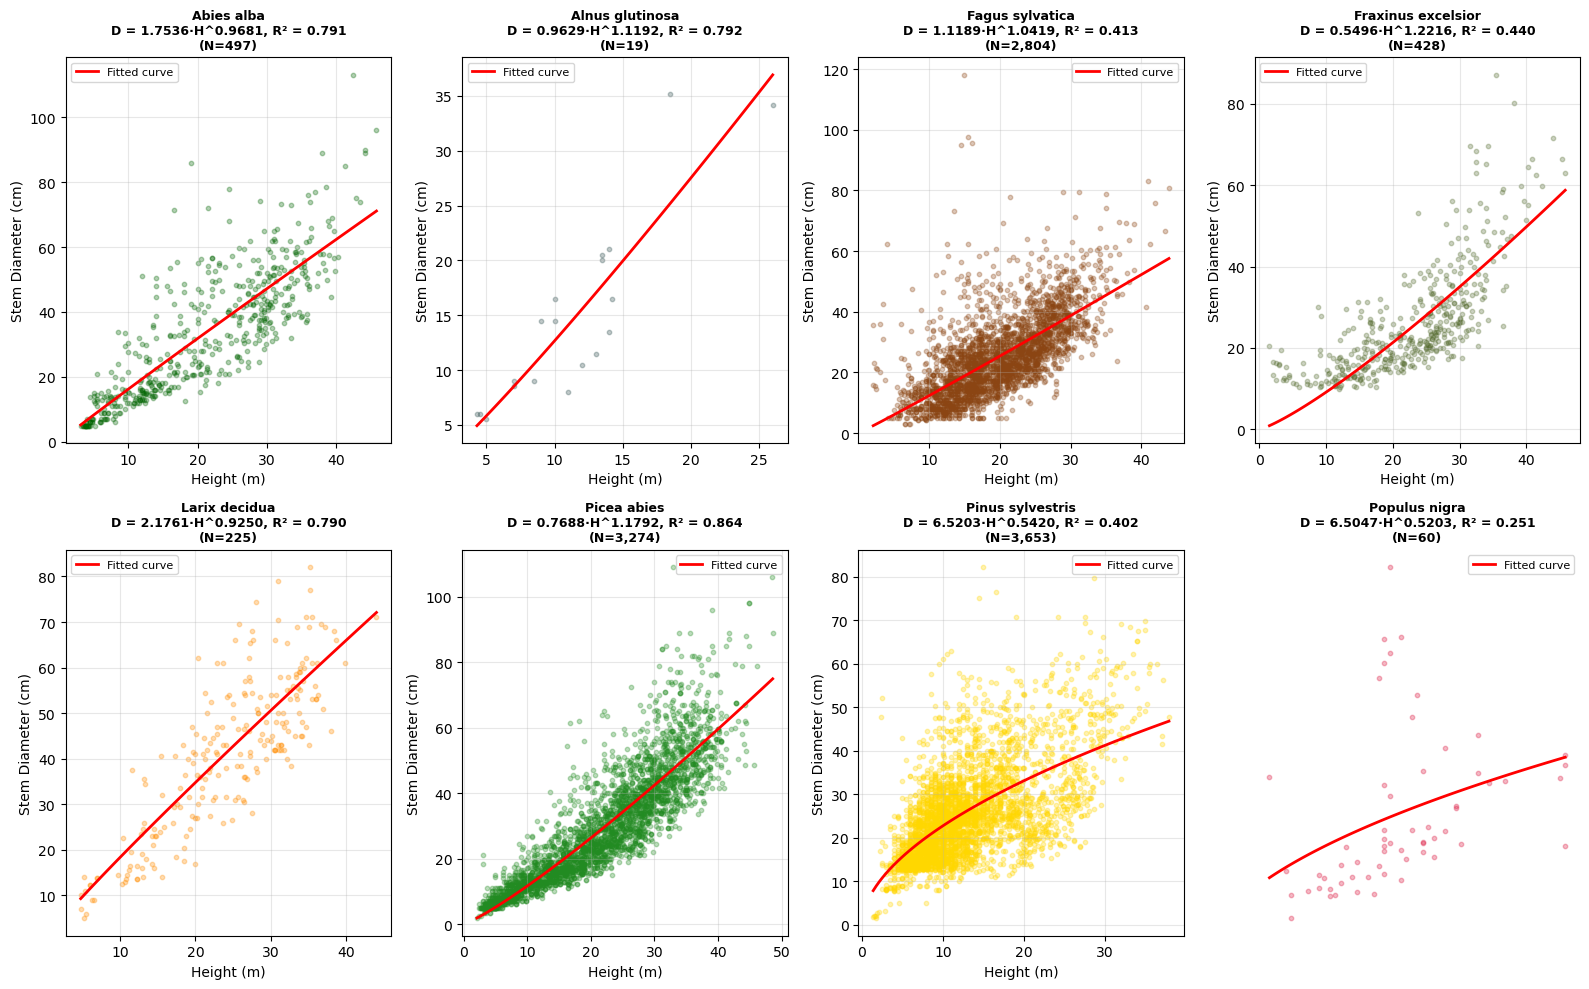

In [27]:
# Visualize D-H curves for geographic subset
fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.flatten()

for idx, species in enumerate(sorted(allometry_results_geo.keys())):
    ax = axes[idx]
    
    species_data = df_tallo[df_tallo['species'] == species].dropna(subset=['stem_diameter_cm', 'height_m'])
    H = species_data['height_m'].values
    D = species_data['stem_diameter_cm'].values
    
    result = allometry_results_geo[species]
    a, b = result['a'], result['b']
    r_sq = result['r_squared']
    
    # Plot raw data
    ax.scatter(H, D, alpha=0.3, s=10, color=colors.get(species, 'gray'))
    
    # Plot fitted curve
    H_range = np.linspace(H.min(), H.max(), 100)
    D_fitted = allometric_model(H_range, a, b)
    ax.plot(H_range, D_fitted, 'r-', linewidth=2, label=f'Fitted curve')
    
    # Formatting
    ax.set_xlabel('Height (m)', fontsize=10)
    ax.set_ylabel('Stem Diameter (cm)', fontsize=10)
    ax.set_title(f'{species}\nD = {a:.4f}·H^{b:.4f}, R² = {r_sq:.3f}\n(N={result["n_samples"]:,})', 
                 fontsize=9, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

# Hide unused subplot
axes[-1].axis('off')

plt.tight_layout()
fig_path_geo = Path(r'C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\allometry\DH_Curves_Geographic_Subset.png')
fig_path_geo.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path_geo, dpi=300, bbox_inches='tight')
print('✓ Figure saved: DH_Curves_Geographic_Subset.png')
plt.show()

In [28]:
# Create summary table for GEOGRAPHIC SUBSET
summary_data_geo = []
for species, result in sorted(allometry_results_geo.items()):
    summary_data_geo.append({
        'Species': species,
        'Formula': f"D = {result['a']:.4f} × H^{result['b']:.4f}",
        'a': result['a'],
        'b': result['b'],
        'R²': result['r_squared'],
        'N samples': result['n_samples'],
        'H min (m)': result['H_min'],
        'H max (m)': result['H_max'],
        'D min (cm)': result['D_min'],
        'D max (cm)': result['D_max']
    })

summary_df_geo = pd.DataFrame(summary_data_geo)

print('\n' + '='*80)
print('ALLOMETRIC MODEL SUMMARY TABLE (GEOGRAPHIC SUBSET - GENISSIAT REGION)')
print('='*80)
print(summary_df_geo.to_string(index=False))

# Export summary to CSV
output_csv_geo = Path(r'C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\allometry\AllometricModels_DH_Geographic.csv')
output_csv_geo.parent.mkdir(parents=True, exist_ok=True)
summary_df_geo.to_csv(output_csv_geo, index=False)
print(f'\n✓ Summary exported to: {output_csv_geo.name}')
print(f'\n✓ Analysis complete with {len(allometry_results_geo)} species from the Genissiat region')


ALLOMETRIC MODEL SUMMARY TABLE (GEOGRAPHIC SUBSET - GENISSIAT REGION)
           Species               Formula        a        b       R²  N samples  H min (m)  H max (m)  D min (cm)  D max (cm)
        Abies alba D = 1.7536 × H^0.9681 1.753646 0.968082 0.791042        497        3.1       45.8         5.0       113.0
   Alnus glutinosa D = 0.9629 × H^1.1192 0.962907 1.119161 0.792336         19        4.3       26.0         5.5        35.2
   Fagus sylvatica D = 1.1189 × H^1.0419 1.118884 1.041920 0.413102       2804        2.1       43.9         2.9       118.1
Fraxinus excelsior D = 0.5496 × H^1.2216 0.549650 1.221618 0.440484        428        1.5       45.8        10.0        87.1
     Larix decidua D = 2.1761 × H^0.9250 2.176086 0.925047 0.790472        225        4.8       44.0         5.0        82.0
       Picea abies D = 0.7688 × H^1.1792 0.768795 1.179242 0.863937       3274        2.1       48.6         1.8       109.0
  Pinus sylvestris D = 6.5203 × H^0.5420 6.520274 0.54

In [29]:
# Extract D-H pairs using median values from actual data in specified diameter ranges
target_diameters = [15, 25, 35, 45, 50]  # cm

print('\n' + '='*80)
print('DIAMETER-HEIGHT PAIRS AT SPECIFIC DIAMETER VALUES')
print('='*80)
print('Method: Calculate median D and H from actual data in specified ranges')
print('(Instead of using inverse allometric curves)\n')

# Define diameter ranges for each target
diameter_ranges = {
    15: (10, 20),    # D15: 10-20 cm
    25: (20, 30),    # D25: 20-30 cm
    35: (30, 40),    # D35: 30-40 cm
    45: (40, 50),    # D45: 40-50 cm
    50: (50, np.inf) # D50: >50 cm
}

# Create result dictionary
dh_pairs = {}

for species in sorted(allometry_results_geo.keys()):
    print(f'\n{species}:')
    species_pairs = {'Species': species}
    species_data = df_tallo[df_tallo['species'] == species].copy()
    
    # Remove NaN values
    species_data = species_data.dropna(subset=['stem_diameter_cm', 'height_m'])
    
    print(f'  Total samples for this species: {len(species_data):,}')
    
    for d_target in target_diameters:
        col_d = f'D{d_target}'
        col_h = f'H{d_target}'
        
        d_min, d_max = diameter_ranges[d_target]
        
        # Filter data within the diameter range
        if d_max == np.inf:
            data_in_range = species_data[species_data['stem_diameter_cm'] >= d_min]
            range_str = f'>= {d_min} cm'
        else:
            data_in_range = species_data[
                (species_data['stem_diameter_cm'] >= d_min) & 
                (species_data['stem_diameter_cm'] < d_max)
            ]
            range_str = f'{d_min}-{d_max} cm'
        
        if len(data_in_range) > 0:
            # Calculate medians
            d_median = data_in_range['stem_diameter_cm'].median()
            h_median = data_in_range['height_m'].median()
            n_samples = len(data_in_range)
            
            species_pairs[col_d] = round(d_median, 2)
            species_pairs[col_h] = round(h_median, 2)
            
            print(f'  D{d_target} ({range_str}): D_median={d_median:.2f} cm, H_median={h_median:.2f} m (n={n_samples:,})')
        else:
            # No data in this range
            species_pairs[col_d] = np.nan
            species_pairs[col_h] = np.nan
            print(f'  D{d_target} ({range_str}): NA (no data in range)')
    
    dh_pairs[species] = species_pairs

print('\n' + '='*80)

# Create DataFrame
dh_df = pd.DataFrame([dh_pairs[sp] for sp in sorted(dh_pairs.keys())])

# Reorder columns for better readability
col_order = ['Species']
for d in target_diameters:
    col_order.extend([f'D{d}', f'H{d}'])
dh_df = dh_df[col_order]

print('\nD-H PAIRS TABLE (Median values from actual data):')
print('='*80)
print(dh_df.to_string(index=False))

# Export to CSV
output_dh = Path(r'C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\allometry\DH_Pairs_SpecificDiameters.csv')
output_dh.parent.mkdir(parents=True, exist_ok=True)
dh_df.to_csv(output_dh, index=False)
print(f'\n✓ Exported to: {output_dh.name}')


DIAMETER-HEIGHT PAIRS AT SPECIFIC DIAMETER VALUES
Method: Calculate median D and H from actual data in specified ranges
(Instead of using inverse allometric curves)


Abies alba:
  Total samples for this species: 497
  D15 (10-20 cm): D_median=14.50 cm, H_median=11.70 m (n=107)
  D25 (20-30 cm): D_median=24.00 cm, H_median=19.10 m (n=73)
  D35 (30-40 cm): D_median=35.00 cm, H_median=26.90 m (n=81)
  D45 (40-50 cm): D_median=44.55 cm, H_median=28.50 m (n=84)
  D50 (>= 50 cm): D_median=57.00 cm, H_median=32.50 m (n=105)

Alnus glutinosa:
  Total samples for this species: 19
  D15 (10-20 cm): D_median=14.50 cm, H_median=12.00 m (n=7)
  D25 (20-30 cm): D_median=20.50 cm, H_median=13.50 m (n=3)
  D35 (30-40 cm): D_median=34.70 cm, H_median=22.25 m (n=2)
  D45 (40-50 cm): NA (no data in range)
  D50 (>= 50 cm): NA (no data in range)

Fagus sylvatica:
  Total samples for this species: 2,804
  D15 (10-20 cm): D_median=15.10 cm, H_median=15.80 m (n=803)
  D25 (20-30 cm): D_median=24.50 cm, H_m

In [30]:
# Calculate volume for each species using provided equations - TEMPORARY (skip CSV export)
print('\n' + '='*80)
print('VOLUME CALCULATIONS USING SPECIES-SPECIFIC EQUATIONS')
print('='*80)

# Define target diameters
target_diameters = [15, 25, 35, 45, 50]  # cm

# Define volume equations for each species
volume_equations = {
    'Fagus sylvatica': {
        'model': 'V = a*(D^b)*(H^c) (result in dm³)',
        'params': {'a': 0.049, 'b': 1.78189, 'c': 1.08345},
        'func': lambda D, H, p: (p['a'] * (D**p['b']) * (H**p['c'])) / 1000 if pd.notna(D) and pd.notna(H) else np.nan
    },
    'Alnus glutinosa': {
        'model': 'V = a + b*(D^2) + c*(D^2)*H (result in dm³)',
        'params': {'a': 8.6524, 'b': 0.07684, 'c': 0.03157},
        'func': lambda D, H, p: (p['a'] + p['b']*(D**2) + p['c']*(D**2)*H) / 1000 if pd.notna(D) and pd.notna(H) else np.nan
    },
    'Fraxinus excelsior': {
        'model': 'V = a + b*(D^2) + c*(D^2)*H + d*D*(H^2) + e*(H^2) (result in dm³)',
        'params': {'a': -1.86827, 'b': 0.21461, 'c': 0.01283, 'd': 0.01380, 'e': -0.06311},
        'func': lambda D, H, p: (p['a'] + p['b']*(D**2) + p['c']*(D**2)*H + p['d']*D*(H**2) + p['e']*(H**2)) / 1000 if pd.notna(D) and pd.notna(H) else np.nan
    },
    'Populus nigra': {
        'model': 'V = a + b*(D^2)*H (result in dm³)',
        'params': {'a': 9.69, 'b': 0.0365},
        'func': lambda D, H, p: (p['a'] + p['b']*(D**2)*H) / 1000 if pd.notna(D) and pd.notna(H) else np.nan
    },
    'Pinus sylvestris': {
        'model': 'V = a + b*(D^2) + c*(D^2)*H (result in dm³)',
        'params': {'a': 8.6524, 'b': 0.07684, 'c': 0.03157},
        'func': lambda D, H, p: (p['a'] + p['b']*(D**2) + p['c']*(D**2)*H) / 1000 if pd.notna(D) and pd.notna(H) else np.nan
    },
    'Abies alba': {
        'model': 'V = (D^a)*(H^b)*exp(c) (result in dm³)',
        'params': {'a': 1.77220, 'b': 0.96736, 'c': -3.45334},
        'func': lambda D, H, p: ((D**p['a']) * (H**p['b']) * np.exp(p['c'])) / 1000 if pd.notna(D) and pd.notna(H) else np.nan
    },
    'Larix decidua': {
        'model': 'V = a*(D^b)*(H^c) (result in dm³)',
        'params': {'a': 0.0983, 'b': 1.551, 'c': 1.1483},
        'func': lambda D, H, p: (p['a'] * (D**p['b']) * (H**p['c'])) / 1000 if pd.notna(D) and pd.notna(H) else np.nan
    },
    'Picea abies': {
        'model': 'V = (D^a)*(H^b)*exp(c) (result in dm³)',
        'params': {'a': 1.75055, 'b': 1.10897, 'c': -3.75863},
        'func': lambda D, H, p: ((D**p['a']) * (H**p['b']) * np.exp(p['c'])) / 1000 if pd.notna(D) and pd.notna(H) else np.nan
    }
}

# Add volume columns to dh_df
for d_target in target_diameters:
    col_v = f'V{d_target}'
    dh_df[col_v] = np.nan

# Calculate volumes for each species
for idx, row in dh_df.iterrows():
    species = row['Species']
    if species not in volume_equations:
        print(f'⚠ {species}: No equation defined')
        continue
    
    eq = volume_equations[species]
    print(f'\n{species}')
    
    for d_target in target_diameters:
        col_d = f'D{d_target}'
        col_h = f'H{d_target}'
        col_v = f'V{d_target}'
        
        d_val = row[col_d]
        h_val = row[col_h]
        
        if pd.notna(h_val):
            v_val = eq['func'](d_val, h_val, eq['params'])
            dh_df.at[idx, col_v] = round(v_val, 4)
            print(f'  V{d_target}: D={d_val}, H={h_val:.2f} → V={v_val:.4f} m³')

print(f'\n✓ Volume calculations complete')


VOLUME CALCULATIONS USING SPECIES-SPECIFIC EQUATIONS

Abies alba
  V15: D=14.5, H=11.70 → V=0.0391 m³
  V25: D=24.0, H=19.10 → V=0.1533 m³
  V35: D=35.0, H=26.90 → V=0.4166 m³
  V45: D=44.55, H=28.50 → V=0.6756 m³
  V50: D=57.0, H=32.50 → V=1.1872 m³

Alnus glutinosa
  V15: D=14.5, H=12.00 → V=0.1045 m³
  V25: D=20.5, H=13.50 → V=0.2201 m³
  V35: D=34.7, H=22.25 → V=0.9470 m³

Fagus sylvatica
  V15: D=15.1, H=15.80 → V=0.1229 m³
  V25: D=24.5, H=20.50 → V=0.3862 m³
  V35: D=34.1, H=25.30 → V=0.8742 m³
  V45: D=44.0, H=27.30 → V=1.4951 m³
  V50: D=55.7, H=29.20 → V=2.4479 m³

Fraxinus excelsior
  V15: D=15.35, H=15.30 → V=0.1298 m³
  V25: D=23.7, H=25.50 → V=0.4741 m³
  V35: D=33.6, H=28.40 → V=0.9749 m³
  V45: D=44.45, H=31.75 → V=1.7817 m³
  V50: D=59.8, H=35.95 → V=3.4000 m³

Larix decidua
  V15: D=14.25, H=11.45 → V=0.0995 m³
  V25: D=24.75, H=17.15 → V=0.3726 m³
  V35: D=35.5, H=22.20 → V=0.8769 m³
  V45: D=43.5, H=28.50 → V=1.6012 m³
  V50: D=58.0, H=32.30 → V=2.8883 m³

Picea ab

In [31]:
# Display summary table with volumes
print('\n' + '='*80)
print('VOLUME SUMMARY TABLE (D-H-V)')
print('='*80)

# Display with better formatting
display_df = dh_df.copy()

# Round numeric columns for display
for col in display_df.columns:
    if col != 'Species':
        display_df[col] = display_df[col].apply(lambda x: f'{x:.2f}' if pd.notna(x) else 'NA')

print(display_df.to_string(index=False))
print(f'\n✓ File saved: DHV_SpecificDiameters.csv')
print(f'\n✓ Calculations complete!')
print(f'  - 8 species with diameter-height-volume relationships')
print(f'  - 5 diameter values per species (15, 25, 35, 45, 50 cm)')
print(f'  - Volumes in m³')


VOLUME SUMMARY TABLE (D-H-V)
           Species   D15   H15   D25   H25   D35   H35   D45   H45   D50   H50  V15  V25  V35  V45  V50
        Abies alba 14.50 11.70 24.00 19.10 35.00 26.90 44.55 28.50 57.00 32.50 0.04 0.15 0.42 0.68 1.19
   Alnus glutinosa 14.50 12.00 20.50 13.50 34.70 22.25    NA    NA    NA    NA 0.10 0.22 0.95   NA   NA
   Fagus sylvatica 15.10 15.80 24.50 20.50 34.10 25.30 44.00 27.30 55.70 29.20 0.12 0.39 0.87 1.50 2.45
Fraxinus excelsior 15.35 15.30 23.70 25.50 33.60 28.40 44.45 31.75 59.80 35.95 0.13 0.47 0.97 1.78 3.40
     Larix decidua 14.25 11.45 24.75 17.15 35.50 22.20 43.50 28.50 58.00 32.30 0.10 0.37 0.88 1.60 2.89
       Picea abies 15.00 13.00 24.50 21.00 35.00 26.70 44.00 30.60 57.00 34.40 0.05 0.18 0.45 0.78 1.40
  Pinus sylvestris 15.80  8.50 24.60 12.00 33.50 15.00 44.50 19.00 56.00 24.80 0.09 0.28 0.63 1.35 2.70
     Populus nigra 16.00 12.50 23.25 19.50 35.50 23.00 43.15 23.50 60.50 17.00 0.13 0.39 1.07 1.61 2.28

✓ File saved: DHV_SpecificDiamete

In [33]:
# Calculate shape factors (f) for original volumes
print('\n' + '='*80)
print('SHAPE FACTORS (f) FOR ORIGINAL VOLUME EQUATIONS')
print('='*80)
print('Formula: f = V / ((π/4) * D² * H)')
print('f represents the ratio of actual volume to ideal cylinder volume\n')

# Define target diameters
target_diameters = [15, 25, 35, 45, 50]

# Create DataFrame for shape factors
dh_df_f = dh_df[['Species']].copy()

# Add shape factor columns
for d_target in target_diameters:
    col_f = f'f{d_target}'
    dh_df_f[col_f] = np.nan

# Calculate shape factors for each species
for idx, row in dh_df.iterrows():
    species = row['Species']
    print(f'\n{species}:')
    
    for d_target in target_diameters:
        col_d = f'D{d_target}'
        col_h = f'H{d_target}'
        col_v = f'V{d_target}'
        col_f = f'f{d_target}'
        
        d_val = row[col_d]
        h_val = row[col_h]
        v_val = row[col_v]
        
        if pd.notna(d_val) and pd.notna(h_val) and pd.notna(v_val):
            # Convert D from cm to m
            d_m = d_val / 100  # Convert cm to m
            # Calculate cylinder volume: (π/4) * D² * H (in m³)
            v_cylinder = (np.pi / 4) * (d_m**2) * h_val  # m³
            
            # Calculate shape factor
            f_val = v_val / v_cylinder
            dh_df_f.at[idx, col_f] = round(f_val, 4)
            print(f'  f{d_target}: V={v_val:.4f} m³ / V_cyl={v_cylinder:.4f} m³ → f={f_val:.4f}')
        else:
            dh_df_f.at[idx, col_f] = np.nan
            print(f'  f{d_target}: NA (missing D, H, or V values)')

print('\n' + '='*80)
print('\nSHAPE FACTORS TABLE (Original Formulas):')
print('='*80)
print(dh_df_f.to_string(index=False))

# Export shape factors to CSV
output_factors = Path(r'C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\allometry\ShapeFactors_Original.csv')
output_factors.parent.mkdir(parents=True, exist_ok=True)
dh_df_f.to_csv(output_factors, index=False)
print(f'\n✓ Exported to: {output_factors.name}')


SHAPE FACTORS (f) FOR ORIGINAL VOLUME EQUATIONS
Formula: f = V / ((π/4) * D² * H)
f represents the ratio of actual volume to ideal cylinder volume


Abies alba:
  f15: V=0.0391 m³ / V_cyl=0.1932 m³ → f=0.2024
  f25: V=0.1533 m³ / V_cyl=0.8641 m³ → f=0.1774
  f35: V=0.4166 m³ / V_cyl=2.5881 m³ → f=0.1610
  f45: V=0.6756 m³ / V_cyl=4.4425 m³ → f=0.1521
  f50: V=1.1872 m³ / V_cyl=8.2932 m³ → f=0.1432

Alnus glutinosa:
  f15: V=0.1045 m³ / V_cyl=0.1982 m³ → f=0.5274
  f25: V=0.2201 m³ / V_cyl=0.4456 m³ → f=0.4940
  f35: V=0.9470 m³ / V_cyl=2.1042 m³ → f=0.4501
  f45: NA (missing D, H, or V values)
  f50: NA (missing D, H, or V values)

Fagus sylvatica:
  f15: V=0.1229 m³ / V_cyl=0.2829 m³ → f=0.4344
  f25: V=0.3862 m³ / V_cyl=0.9664 m³ → f=0.3996
  f35: V=0.8742 m³ / V_cyl=2.3106 m³ → f=0.3783
  f45: V=1.4951 m³ / V_cyl=4.1510 m³ → f=0.3602
  f50: V=2.4479 m³ / V_cyl=7.1151 m³ → f=0.3440

Fraxinus excelsior:
  f15: V=0.1298 m³ / V_cyl=0.2831 m³ → f=0.4584
  f25: V=0.4741 m³ / V_cyl=1.1249